# part1 : gradient descent 

### Summary:

1. **Backtracking Line Search**:
   Adjusts the step size \( \alpha \) to ensure sufficient decrease in \( f \), based on the condition:
   $$
   f(x - \alpha \nabla f(x)) \leq f(x) - c \alpha ||\nabla f(x)||^2
   $$
   The step size is reduced iteratively until this condition is satisfied.

2. **Gradient Descent (GD)**:
   Iteratively updates the solution using:
   $$
   x_{k+1} = x_k - \alpha \nabla f(x_k)
   $$
   Stops when the gradient is small or the change in \( x_k \) is negligible, or after a maximum number of iterations.

3. **Outputs**:
   - Sequence of solutions \( x_k \), number of iterations, function values, gradients, and error norms.

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import random
from random import randint

In [104]:
def backtracking(f, grad_f, x, alpha = 1, c = 0.8, tau = 0.25):
    while f(x - alpha*grad_f(x)) > f(x) - c * alpha * np.linalg.norm(grad_f(x)) ** 2:
        alpha = tau * alpha
        if alpha < 1e-3:
            break
    return alpha

In [105]:
def GD(f, grad_f, x0, tolf, tolx, kmax, alpha= 1, bt= False):
    """
    The function returns the following:
	•	The sequence of solutions  x_k  at each iteration.
	•	The total number of iterations.
	•	The function values  f(x_k)  at each iteration.
	•	The gradient values  \nabla f(x_k)  at each iteration.
	•	The gradient norms (errors) at each iteration.
 """
    xk = x0
    f_vals = [f(xk)]
    grad_vals = [grad_f(xk)]
    err_vals = [np.linalg.norm(grad_f(xk))]
    x_vals = [xk]
    iteration = 0

    while iteration < kmax:
        x_prec = xk

        xk = xk - alpha * grad_f(xk)

        if bt:
            alpha = backtracking(f, grad_f, xk)

        x_vals.append(xk)
        f_vals.append(f(xk))
        grad_vals.append(grad_f(xk))       
        err_vals.append(np.linalg.norm(grad_f(xk)))

        iteration+=1

        if np.linalg.norm(grad_f(xk)) < tolf * np.linalg.norm(grad_f(x0)):
            break

        if np.linalg.norm(xk - x_prec) < tolx * np.linalg.norm(x0):
            break

    return (x_vals, iteration, f_vals, grad_vals, err_vals)

In [106]:


def my_plot(xk_vals, k, f_vals, grad_vals, err_vals, f, title, with_contour=True):
    # Create a grid of x1 and x2 values for the contour plot
    xv = np.linspace(-10, 10, 100).T
    yv = np.linspace(-10, 10, 100).T
    xx, yy = np.meshgrid(xv, yv)
    
    # Calculate the objective function values on the grid
    zz = f([xx, yy])

    # Convert xk_vals to numpy array
    xk_vals = np.array(xk_vals)

    # If with_contour is True, plot the contours
    if with_contour:
        plt.contour(xx, yy, zz)
    
    # Plot the optimization path (xk_vals) with label
    plt.plot(xk_vals[:,0], xk_vals[:,1], '--ro', label="Optimization path")
    
    # Scatter the true minimum point with label
    plt.scatter(xtrue[0], xtrue[1], color='green', label="True minimum", marker='X',s=150)

    # Add the legend
    plt.legend()

    # Set the title, labels, and grid
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid()
    
    # Display the plot
    plt.show()

def my_plot_2D(xk_vals, k, f_vals, grad_valks, err_vals, f, title):
    x_vals = np.linspace(-3, 3, 100)
    y_vals = []
    for x in x_vals:
        y_vals.append(f([x]))
    plt.plot(x_vals, y_vals)
    plt.scatter(xk_vals, f_vals, c='green')
    plt.title(title)
    plt.show()

def plot_error(iters, errs, labels, title = "Error (2-norms of gradient)"):
    colors = []

    for i in range (len(iters)):
        colors.append('#%06X' % randint(0, 0xFFFFFF))

    colors = plt.get_cmap("tab20c")
    i= 0

    for item in zip(iters, errs, labels):
        plt.plot(item[0], item[1], c=colors(i/(len(iters)-1)), label = item[2])
        i+=1
    plt.title(title)
    
    plt.legend(loc="upper left")
    plt.show()

In [107]:
def function_testing(f, grad_f, x0=0, title="", alpha = 1e-1, bt = False, oneD = False, check_err = False, xtrue = None, isMatr = False):
    # Set tolerance values for stopping criteria
    tolf = 1e-8
    tolx = 1e-8
    kmax = 300

    # Perform gradient descent (GD), with or without backtracking
    if not bt:
        xk_vals, k, f_vals, grad_vals, err_vals = GD(f, grad_f, x0, tolf, tolx, kmax, alpha)
    else:
        # Use backtracking line search to adjust alpha
        alpha_bt = backtracking(f, grad_f, x0)
        xk_vals, k, f_vals, grad_vals, err_vals = GD(f, grad_f, x0, tolf, tolx, kmax, alpha_bt, bt=True)

    # Plot results: either with or without contours
    if not oneD and not isMatr:
        if not bt:
            my_plot(xk_vals, k, f_vals, grad_vals, err_vals, f, title + " with alpha= " + str(alpha), with_contour=True)
            my_plot(xk_vals, k, f_vals, grad_vals, err_vals, f, title + " with alpha= " + str(alpha), with_contour=False)
        else:
            my_plot(xk_vals, k, f_vals, grad_vals, err_vals, f, title + " with backtracking", with_contour=True)
            my_plot(xk_vals, k, f_vals, grad_vals, err_vals, f, title + " with backtracking", with_contour=False)

    elif not isMatr:
        if not bt:
            my_plot_2D(xk_vals, k, f_vals, grad_vals, err_vals, f, title + " with alpha= " + str(alpha))
        else:
            my_plot_2D(xk_vals, k, f_vals, grad_vals, err_vals, f, title + " with backtracking")

    # Print the found minimum and the number of iterations
    print("Minimum Found =", xk_vals[k-1], "with", k, "iterations")
    
    to_ret = []
    
    # If check_err is True, calculate error at each iteration
    if check_err:
        if not isMatr:
            for xk in xk_vals:
                to_ret.append(np.linalg.norm((xk - xtrue)))  # Error as the norm of the difference to true solution
        else:
            xtrue = np.array(xtrue)
            for xk in xk_vals:
                xk = np.array(xk)
                to_ret.append(np.linalg.norm((xk - xtrue)))  # Error as the norm of the difference to true solution
    
    # Return the results
    if check_err:
        return np.arange(k+1), err_vals, to_ret  # Iterations, errors, and error relative to true solution
    return np.arange(k+1), err_vals  # Just iterations and errors

## functions:
![Sample Image](h3_func.png)

In [108]:
random.seed(42)
lam = random.random()

def f1(x):
    return ((x[0] - 3)**2 + (x[1] - 1)**2)
def f2(x):
    return (10*(x[0] - 1)**2 + (x[1] - 2)**2)
def f3(x):
    x = np.array(x).T
    n = len(x)
    v = np.linspace(0, 1, n)
    A = np.vander(v)
    x_true = np.ones(n).T
    b= A @ x_true

    return ((np.linalg.norm((A @ x) - b)**2)/2)
def f4(x):
    n = len(x)
    v = np.linspace(0, 1, n)
    A = np.vander(v)
    x_true = np.ones(n).T
    b= A @ x_true

    return (((np.linalg.norm((A @ x) - b)**2)/2) + ((np.linalg.norm(x))**2)*lam/2)
def f5(x):
    return x[0]**4 + x[0]**3 - 2*(x[0]**2) - 2*x[0]

In [109]:
def grad_f1(x):
    return np.array((2*x[0] - 6, 2*x[1] - 2))
def grad_f2(x):
    return np.array([20*(x[0] - 1), 2*(x[1] - 2)])
def grad_f3(x):
    n = len(x)     
    v = np.linspace(0,1,n)
    A = np.vander(v)   
    x_true = np.ones(n).T    
    b = A @ x_true   
    return A.T@(A@x-b)
def grad_f4(x):
    return grad_f3(x) + lam*np.array(x)
def grad_f5(x):
    return np.array(4*x[0]**3 + 3*x[0]**2 - 4*x[0] - 2)

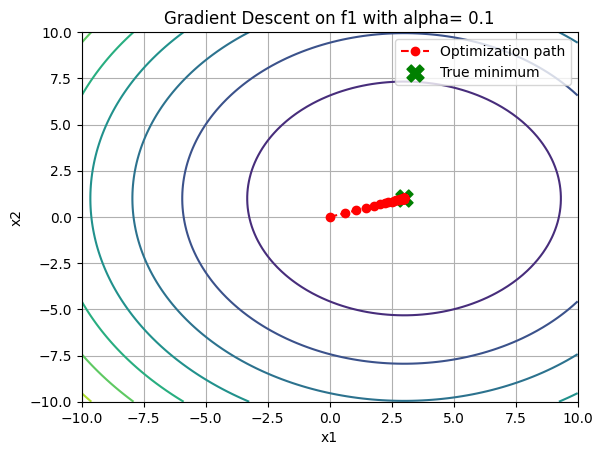

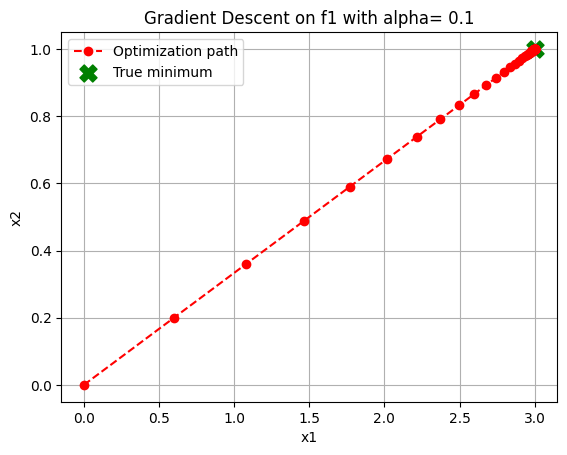

Minimum Found = [2.99999997 0.99999999] with 83 iterations


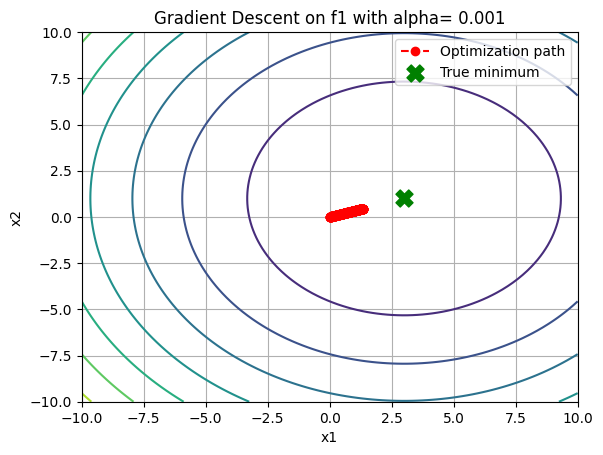

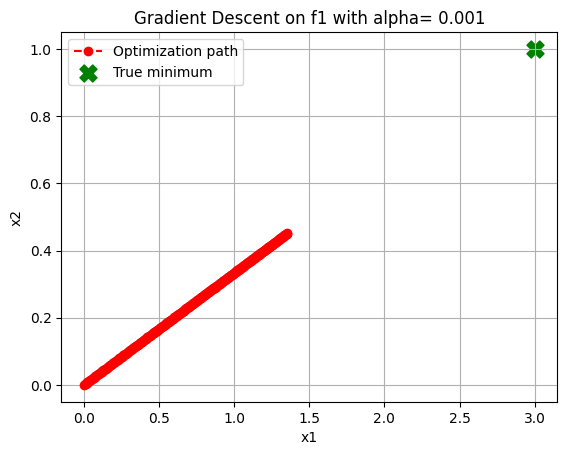

Minimum Found = [1.35125649 0.45041883] with 300 iterations


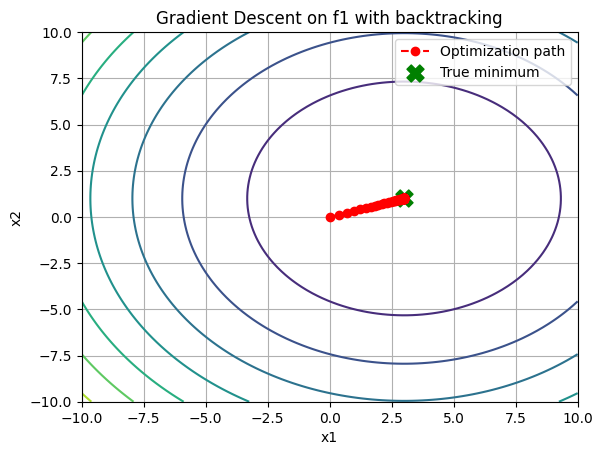

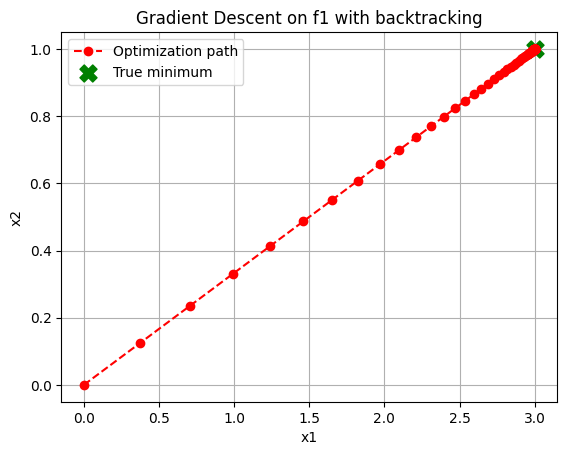

Minimum Found = [2.99999997 0.99999999] with 138 iterations


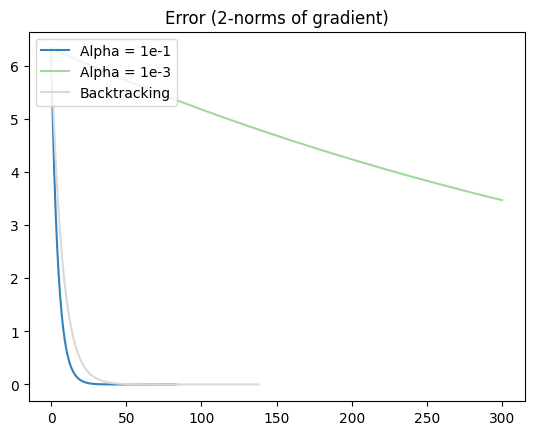

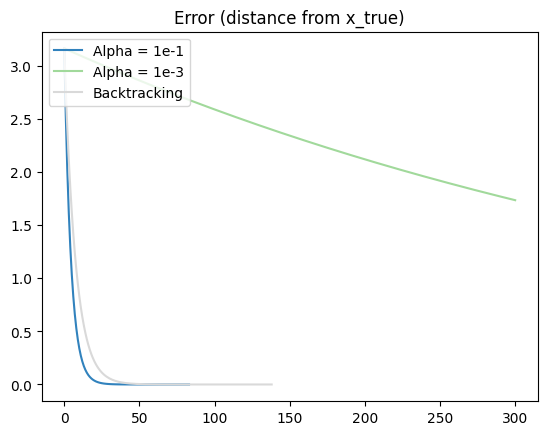

In [110]:
iters = []
err_vals = []
labels = []
err_xtrue = []
xtrue = np.array([3,1]).T
el1, el2, el3 = function_testing(f1, grad_f1, x0 = np.array((0, 0)), title="Gradient Descent on f1", alpha=1e-1, check_err = True, xtrue = xtrue)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-1")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f1, grad_f1, x0 = np.array((0, 0)), title="Gradient Descent on f1", alpha=1e-3, check_err = True, xtrue = xtrue)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-3")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f1, grad_f1, x0 = np.array((0, 0)), title="Gradient Descent on f1", bt = True, check_err = True, xtrue = xtrue)
iters.append(el1)
err_vals.append(el2)
labels.append("Backtracking")
err_xtrue.append(el3)

plot_error(iters, err_vals, labels)
plot_error(iters, err_xtrue, labels, title="Error (distance from x_true)")

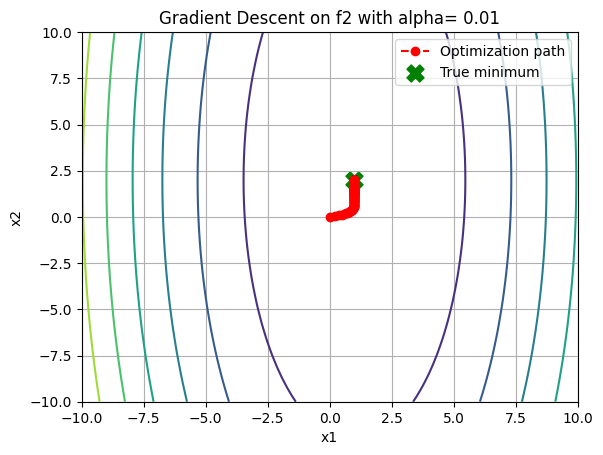

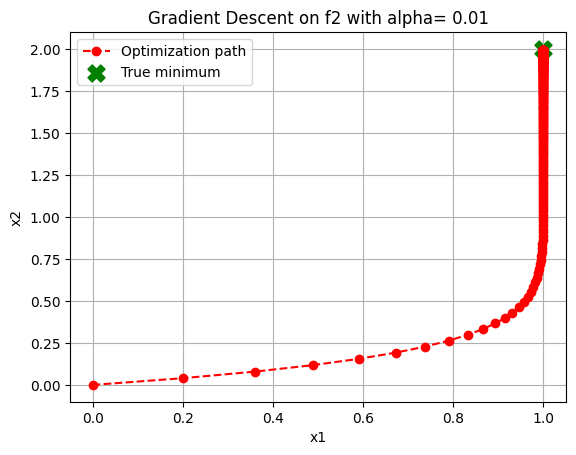

Minimum Found = [1.         1.99523978] with 300 iterations


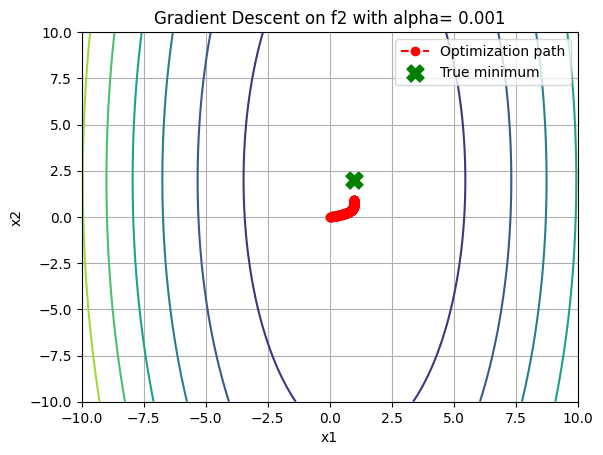

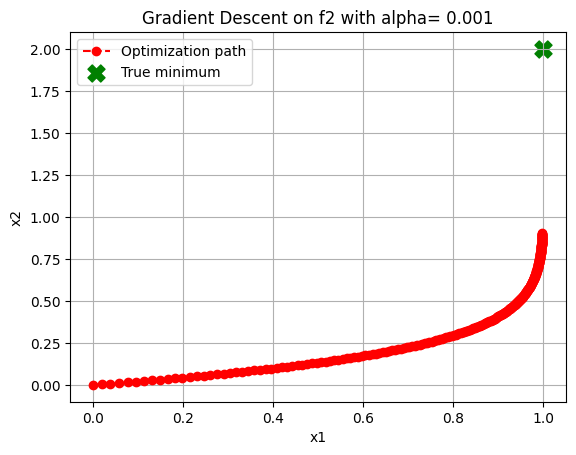

Minimum Found = [0.99761989 0.90083766] with 300 iterations


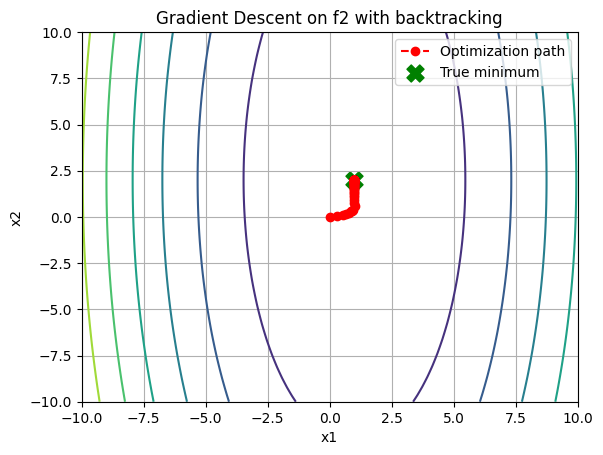

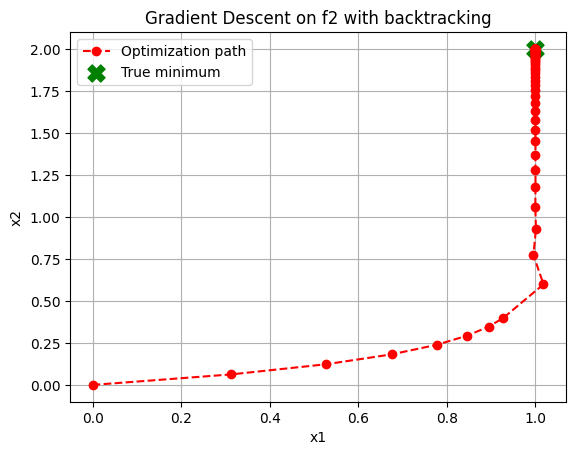

Minimum Found = [1.        1.9999999] with 132 iterations


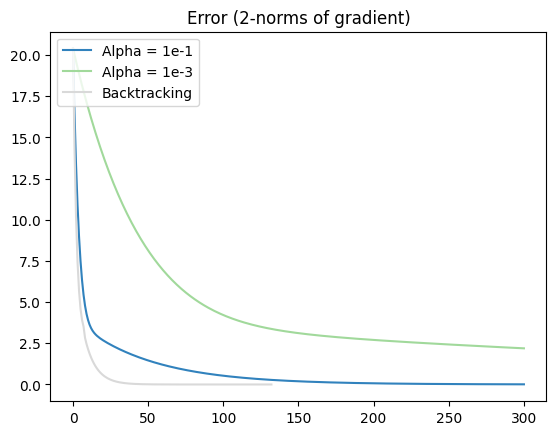

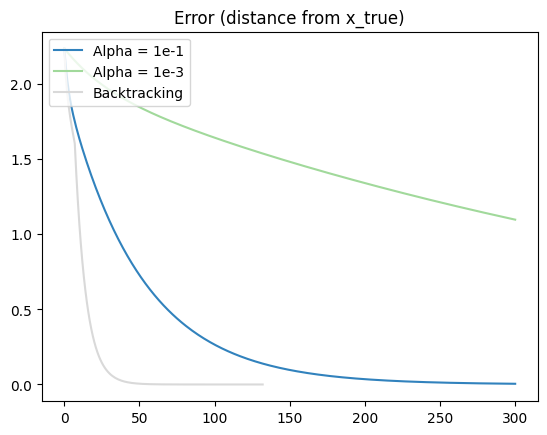

In [111]:
iters = []
err_vals = []
labels = []
err_xtrue = []
xtrue = np.array([1,2]).T

el1, el2, el3 = function_testing(f2, grad_f2, x0 = np.array((0, 0)), title="Gradient Descent on f2", alpha=1e-2, check_err=True, xtrue=xtrue)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-1")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f2, grad_f2, x0 = np.array((0, 0)), title="Gradient Descent on f2", alpha=1e-3, check_err=True, xtrue=xtrue)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-3")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f2, grad_f2, x0 = np.array((0, 0)), title="Gradient Descent on f2", bt = True, check_err=True, xtrue=xtrue)
iters.append(el1)
err_vals.append(el2)
labels.append("Backtracking")
err_xtrue.append(el3)

plot_error(iters, err_vals, labels)
plot_error(iters, err_xtrue, labels, title="Error (distance from x_true)")

n = 1


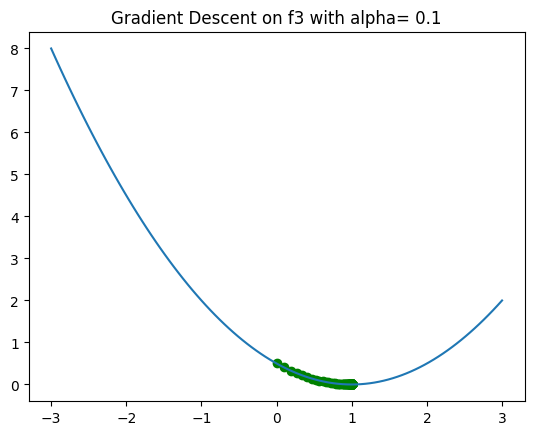

Minimum Found = [0.99999999] with 175 iterations


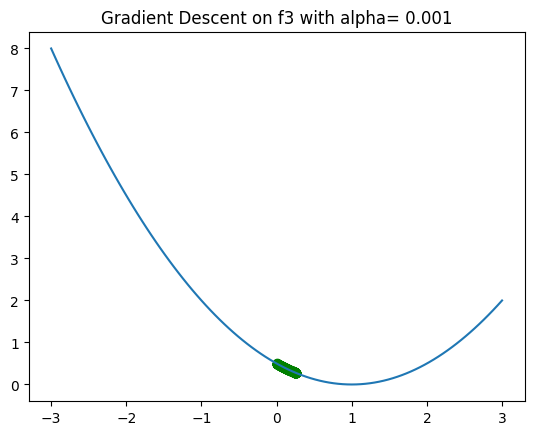

Minimum Found = [0.25855152] with 300 iterations


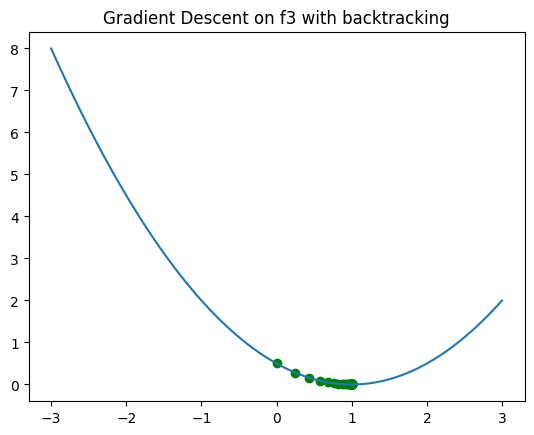

Minimum Found = [0.99999999] with 65 iterations


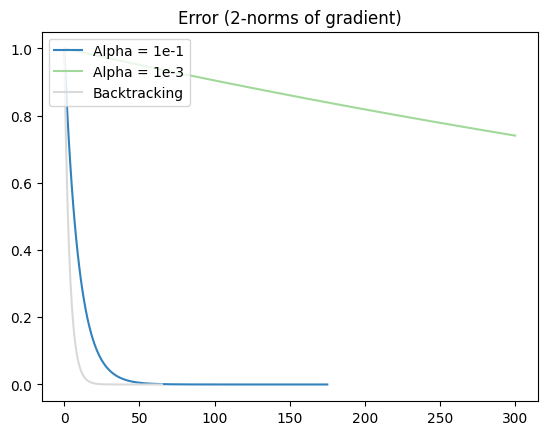

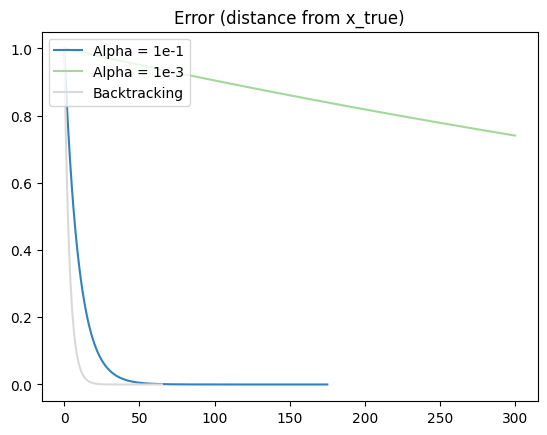

In [112]:
iters = []
err_vals = []
labels = []
err_xtrue = []

print("n = 1")
xtrue = np.ones(1).T

el1, el2, el3 = function_testing(f3, grad_f3, x0 = [0], title="Gradient Descent on f3", alpha=1e-1, check_err = True, xtrue = xtrue, oneD = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-1")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f3, grad_f3, x0 = [0], title="Gradient Descent on f3", alpha=1e-3, check_err = True, xtrue = xtrue, oneD = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-3")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f3, grad_f3, x0 = [0], title="Gradient Descent on f3", bt = True, check_err = True, xtrue = xtrue, oneD = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Backtracking")
err_xtrue.append(el3)

plot_error(iters, err_vals, labels)
plot_error(iters, err_xtrue, labels, title="Error (distance from x_true)")

n = 5
Minimum Found = [0.99163637 1.00089691 1.00736081 1.00026101 0.99911969] with 300 iterations
Minimum Found = [0.70041381 0.74416544 0.81164195 0.92495403 1.18560809] with 300 iterations
Minimum Found = [0.99477693 1.00214716 1.0061874  0.99660827 1.00014983] with 300 iterations


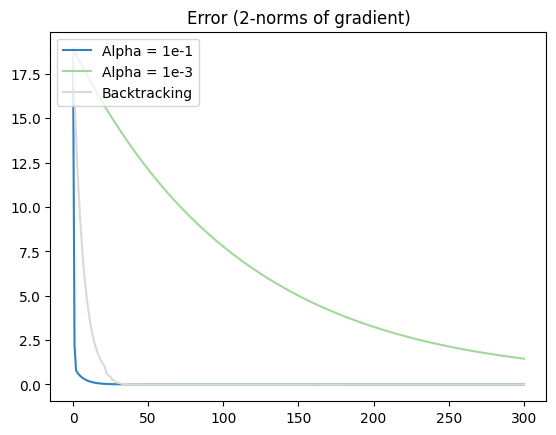

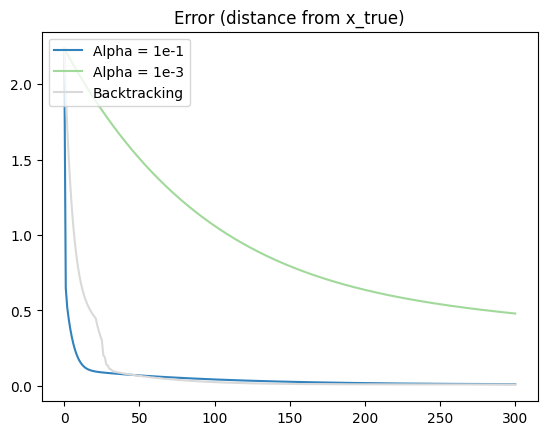

In [113]:
iters = []
err_vals = []
labels = []
err_xtrue = []

print("n = 5")
xtrue = np.ones(5).T
x0 = np.zeros(5)

el1, el2, el3 = function_testing(f3, grad_f3, x0 = x0, title="Gradient Descent on f3", alpha=1e-1, check_err = True, xtrue = xtrue, isMatr = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-1")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f3, grad_f3, x0 = x0, title="Gradient Descent on f3", alpha=1e-3, check_err = True, xtrue = xtrue, isMatr = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-3")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f3, grad_f3, x0 = x0, title="Gradient Descent on f3", bt = True, check_err = True, xtrue = xtrue, isMatr = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Backtracking")
err_xtrue.append(el3)

plot_error(iters, err_vals, labels)
plot_error(iters, err_xtrue, labels, title="Error (distance from x_true)")

n = 10
Minimum Found = [0.95648348 0.96778171 0.98009988 0.99324474 1.00672423 1.01944161
 1.02904177 1.03046867 1.01291279 0.98395632] with 300 iterations
Minimum Found = [0.80664727 0.82637928 0.84966776 0.87735209 0.91052437 0.95059288
 0.99926579 1.05802231 1.124548   1.13978212] with 300 iterations
Minimum Found = [0.99222119 0.99611011 0.99977037 1.00287691 1.00494811 1.00532155
 1.0032568  0.9986253  0.99524933 1.00096048] with 300 iterations


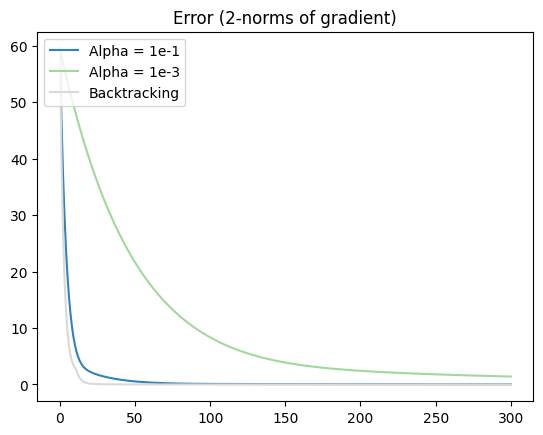

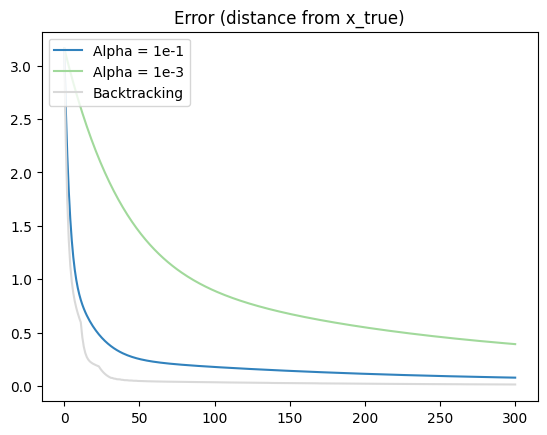

In [114]:
iters = []
err_vals = []
labels = []
err_xtrue = []

print("n = 10")
xtrue = np.ones(10).T
x0 = np.zeros(10)

el1, el2, el3 = function_testing(f3, grad_f3, x0 = x0, title="Gradient Descent on f3", alpha=1e-2, check_err = True, xtrue = xtrue, isMatr = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-1")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f3, grad_f3, x0 = x0, title="Gradient Descent on f3", alpha=1e-3, check_err = True, xtrue = xtrue, isMatr = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-3")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f3, grad_f3, x0 = x0, title="Gradient Descent on f3", bt = True, check_err = True, xtrue = xtrue, isMatr = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Backtracking")
err_xtrue.append(el3)

plot_error(iters, err_vals, labels)
plot_error(iters, err_xtrue, labels, title="Error (distance from x_true)")

n = 1


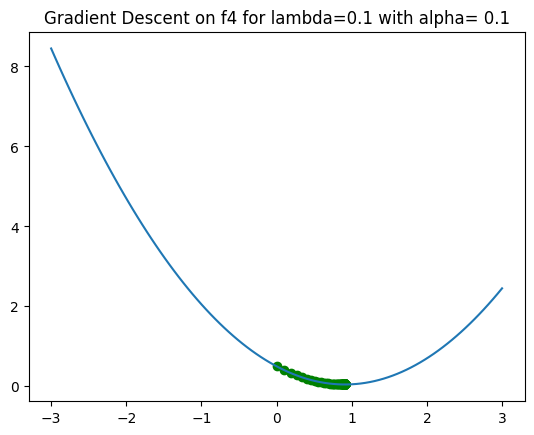

Minimum Found = [0.9090909] with 159 iterations


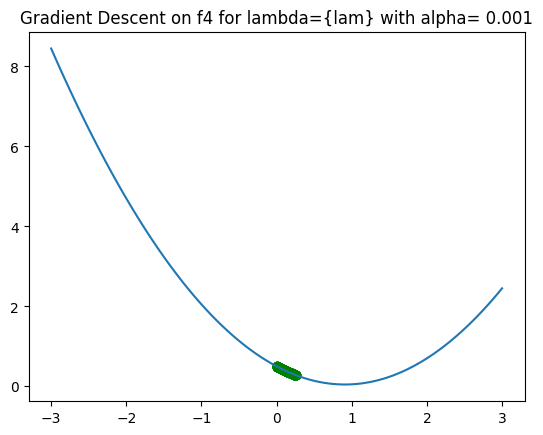

Minimum Found = [0.25492299] with 300 iterations


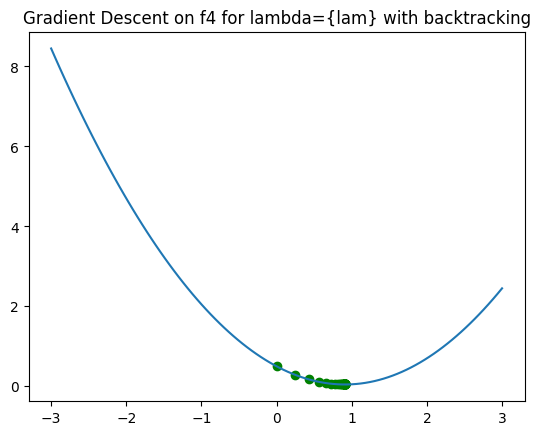

Minimum Found = [0.9090909] with 58 iterations


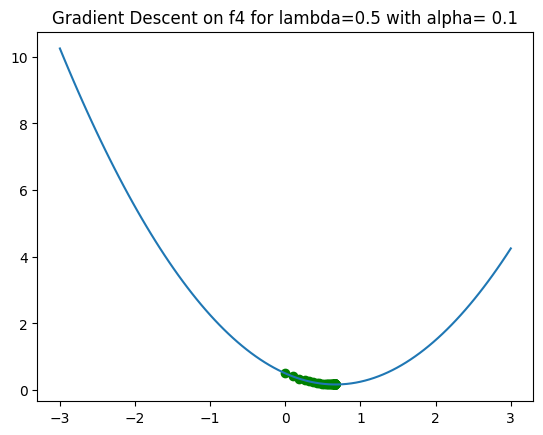

Minimum Found = [0.66666666] with 114 iterations


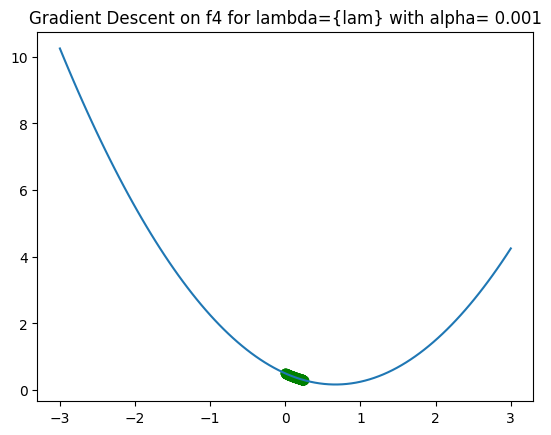

Minimum Found = [0.24108645] with 300 iterations


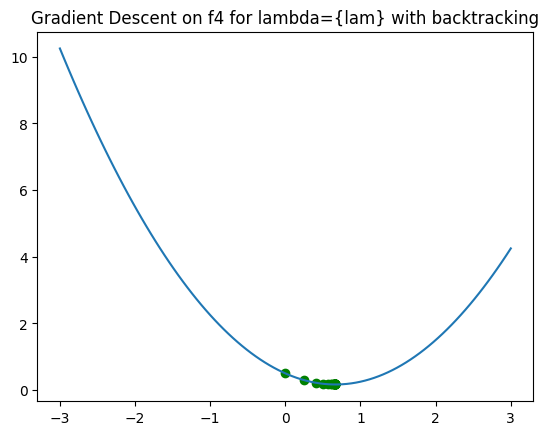

Minimum Found = [0.66666666] with 40 iterations


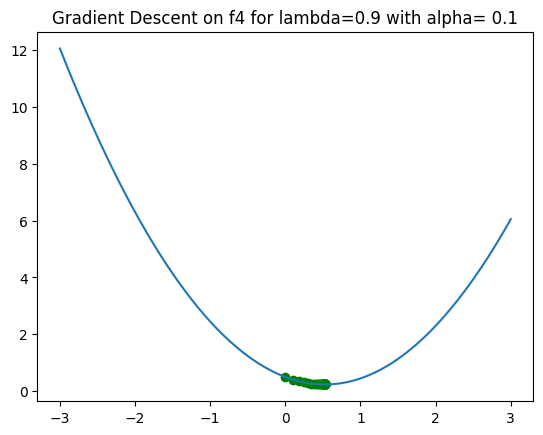

Minimum Found = [0.52631578] with 88 iterations


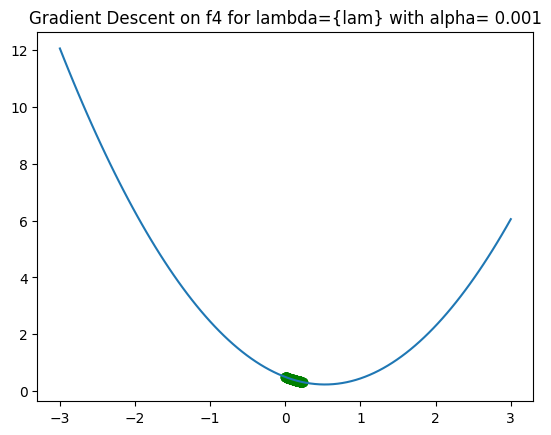

Minimum Found = [0.22826586] with 300 iterations


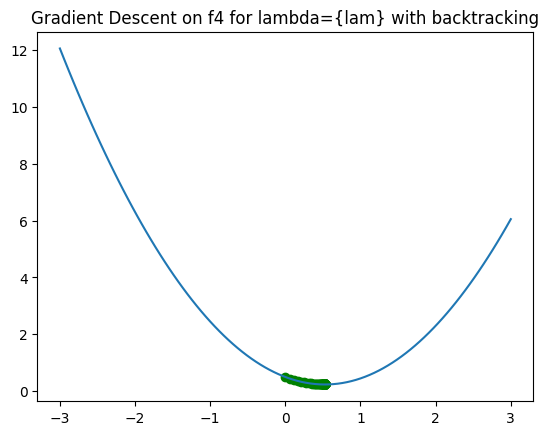

Minimum Found = [0.52631578] with 139 iterations


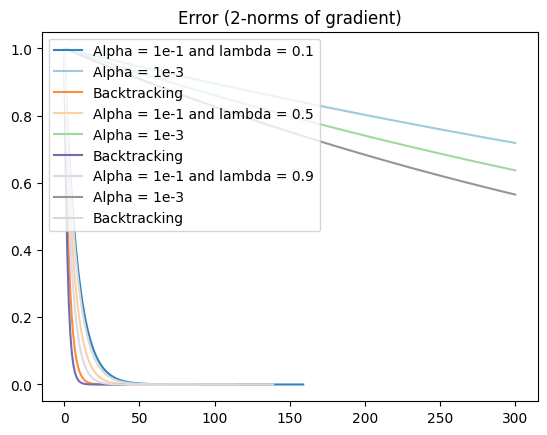

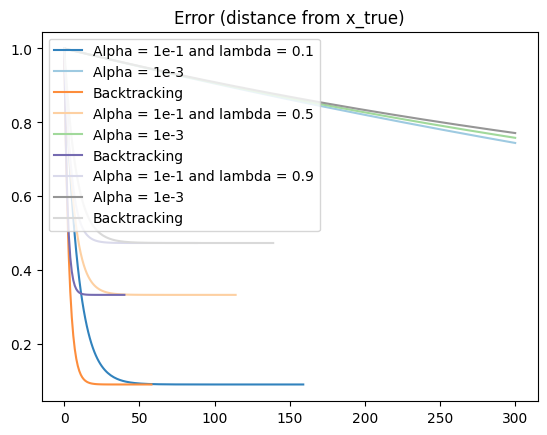

In [115]:
iters = []
err_vals = []
labels = []
err_xtrue = []
lam =[0.1,0.5,0.9]

print("n = 1")
xtrue = np.ones(1).T
for i in lam:
    lam = i

    el1, el2, el3 = function_testing(f4, grad_f4, x0 = [0], title=f"Gradient Descent on f4 for lambda={lam}", alpha=1e-1, check_err = True, xtrue = xtrue, oneD = True)
    
    iters.append(el1)
    err_vals.append(el2)
    labels.append(f"Alpha = 1e-1 and lambda = {lam}")
    err_xtrue.append(el3)

    el1, el2, el3 = function_testing(f4, grad_f4, x0 = [0], title="Gradient Descent on f4 for lambda={lam}", alpha=1e-3, check_err = True, xtrue = xtrue, oneD = True)
    iters.append(el1)
    err_vals.append(el2)
    labels.append("Alpha = 1e-3")
    err_xtrue.append(el3)

    el1, el2, el3 = function_testing(f4, grad_f4, x0 = [0], title="Gradient Descent on f4 for lambda={lam}", bt = True, check_err = True, xtrue = xtrue, oneD = True)
    iters.append(el1)
    err_vals.append(el2)
    labels.append("Backtracking")
    err_xtrue.append(el3)

plot_error(iters, err_vals, labels)
plot_error(iters, err_xtrue, labels, title="Error (distance from x_true)")

n = 5
Minimum Found = [0.76993005 0.80585415 0.85763082 0.93466091 1.02572651] with 105 iterations
Minimum Found = [0.64299981 0.68372015 0.74670989 0.85301257 1.10266371] with 300 iterations
Minimum Found = [0.76993003 0.80585414 0.85763082 0.93466094 1.0257265 ] with 92 iterations


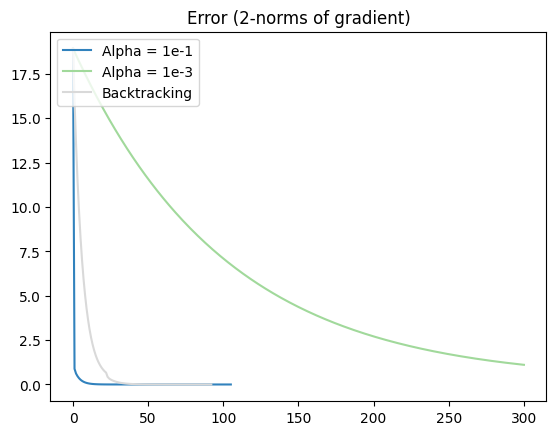

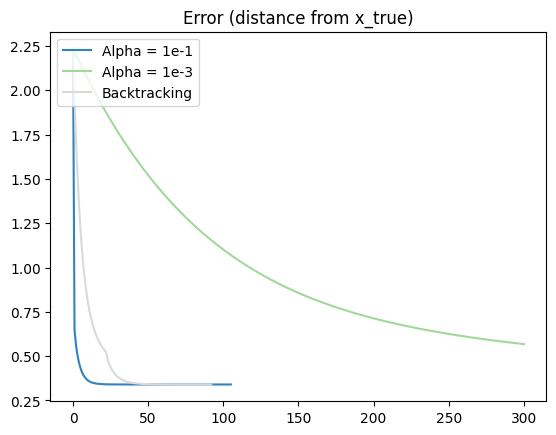

In [116]:
iters = []
err_vals = []
labels = []
err_xtrue = []

print("n = 5")
xtrue = np.ones(5).T
x0 = np.zeros(5)

el1, el2, el3 = function_testing(f4, grad_f4, x0 = x0, title="Gradient Descent on f4", alpha=1e-1, check_err = True, xtrue = xtrue, isMatr = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-1")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f4, grad_f4, x0 = x0, title="Gradient Descent on f4", alpha=1e-3, check_err = True, xtrue = xtrue, isMatr = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-3")
err_xtrue.append(el3)

el1, el2, el3 = function_testing(f4, grad_f4, x0 = x0, title="Gradient Descent on f4", bt = True, check_err = True, xtrue = xtrue, isMatr = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Backtracking")
err_xtrue.append(el3)

plot_error(iters, err_vals, labels)
plot_error(iters, err_xtrue, labels, title="Error (distance from x_true)")

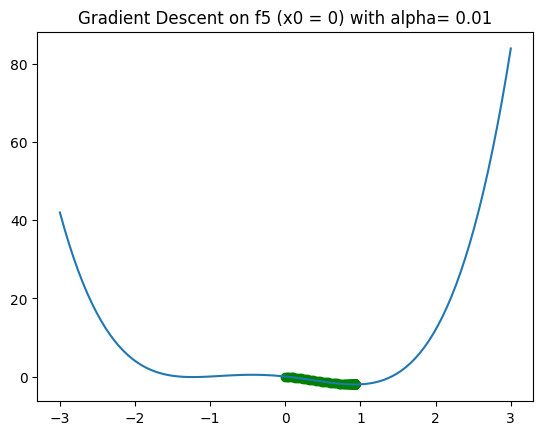

Minimum Found = [0.92222479] with 180 iterations


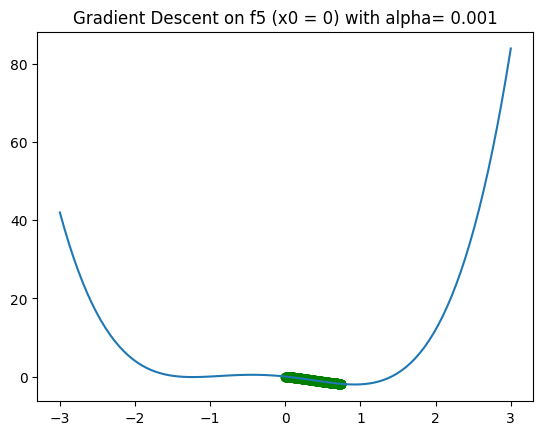

Minimum Found = [0.74222729] with 300 iterations


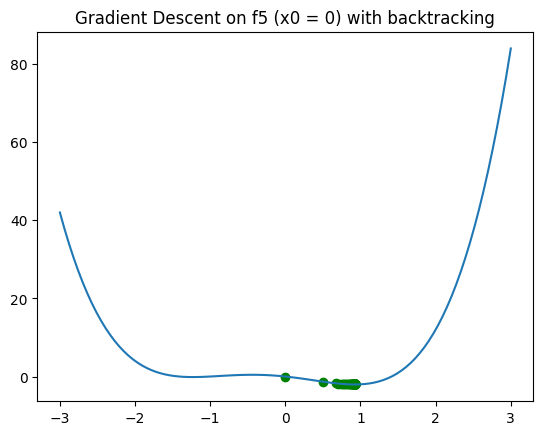

Minimum Found = [0.9222248] with 95 iterations


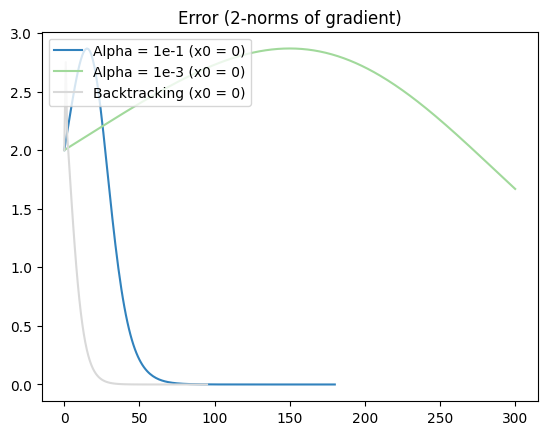

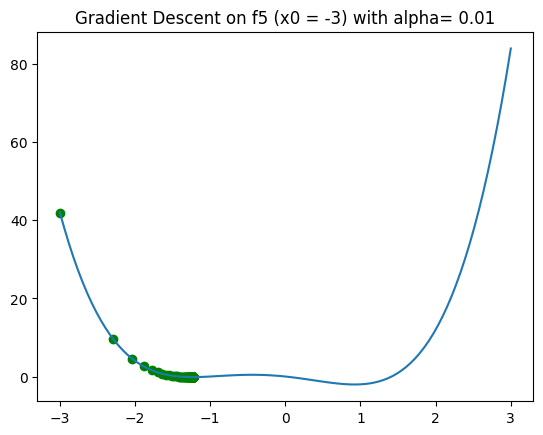

Minimum Found = [-1.23224005] with 193 iterations


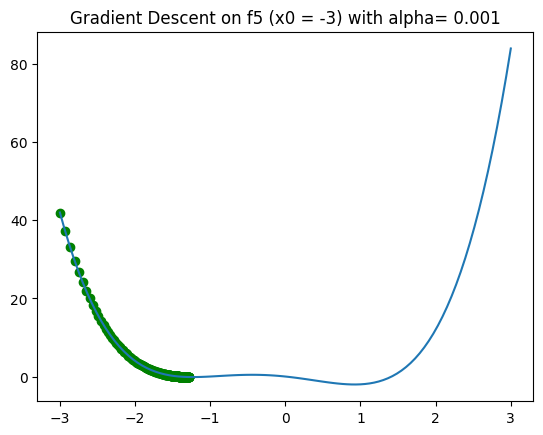

Minimum Found = [-1.28699186] with 300 iterations


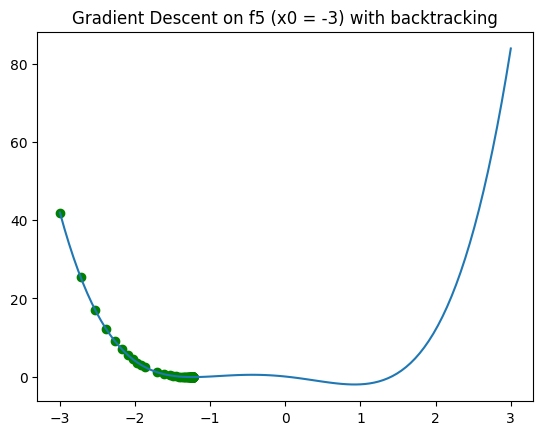

Minimum Found = [-1.2322399] with 133 iterations


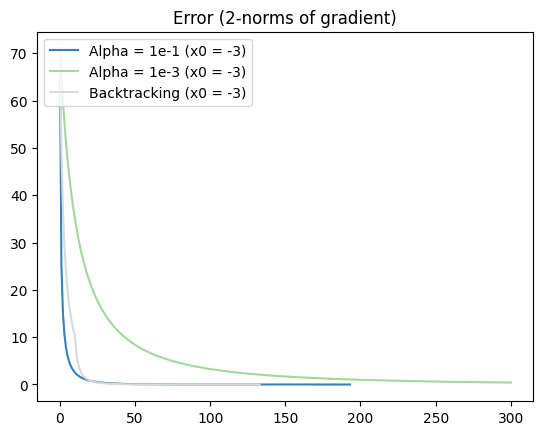

In [117]:
iters = []
err_vals = []
labels = []

el1, el2 = function_testing(f5, grad_f5, x0 = [0], title="Gradient Descent on f5 (x0 = 0)", alpha=1e-2, oneD = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-1 (x0 = 0)")

el1, el2 = function_testing(f5, grad_f5, x0 = [0], title="Gradient Descent on f5 (x0 = 0)", alpha=1e-3, oneD = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-3 (x0 = 0)")

el1, el2 = function_testing(f5, grad_f5, x0 = [0], title="Gradient Descent on f5 (x0 = 0)", bt = True, oneD = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Backtracking (x0 = 0)")

plot_error(iters, err_vals, labels)
iters = []
err_vals = []
labels = []

el1, el2 = function_testing(f5, grad_f5, x0 = [-3], title="Gradient Descent on f5 (x0 = -3)", alpha=1e-2, oneD = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-1 (x0 = -3)")

el1, el2 = function_testing(f5, grad_f5, x0 = [-3], title="Gradient Descent on f5 (x0 = -3)", alpha=1e-3, oneD = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Alpha = 1e-3 (x0 = -3)")

el1, el2 = function_testing(f5, grad_f5, x0 = [-3], title="Gradient Descent on f5 (x0 = -3)", bt = True, oneD = True)
iters.append(el1)
err_vals.append(el2)
labels.append("Backtracking (x0 = -3)")

plot_error(iters, err_vals, labels)

# part2 : SGD

	•	Without Replacement: The np.random.shuffle function ensures that the samples for each batch come from the shuffled dataset, meaning that no sample is reused within a single batch.
	•	Batch Size: The batches are taken in chunks of batch_size, and since shuffling happens at the start of each epoch, the dataset is fully used once per epoch without repeating any elements within the same epoch.



Evaluating with Polynomial Degree = 1
Parameters (SGD) for degree 1: [7.85363328e-04 9.41256563e-01]
Parameters (GD) for degree 1: [-0.00470494  0.60005812]
MSE (SGD - Train) for degree 1: 0.11575939459638392
MSE (GD - Train) for degree 1: 0.23392433824568953
MSE (SGD - Test) for degree 1: 0.1315382073113079
MSE (GD - Test) for degree 1: 0.2280479130120618

Evaluating with Polynomial Degree = 2
Parameters (SGD) for degree 2: [ 0.19920432  0.94137648 -0.19716102]
Parameters (GD) for degree 2: [ 0.03581835  0.59211634 -0.08399159]
MSE (SGD - Train) for degree 2: 0.08442751491106579
MSE (GD - Train) for degree 2: 0.22085352548403678
MSE (SGD - Test) for degree 2: 0.09129059867573468
MSE (GD - Test) for degree 2: 0.2154358815079619

Evaluating with Polynomial Degree = 3
Parameters (SGD) for degree 3: [ 0.19745274  1.43504274 -0.19900099 -0.27322137]
Parameters (GD) for degree 3: [ 0.04175462  0.32183943 -0.08501437  0.26091876]
MSE (SGD - Train) for degree 3: 0.03818489105959236
MSE (GD -

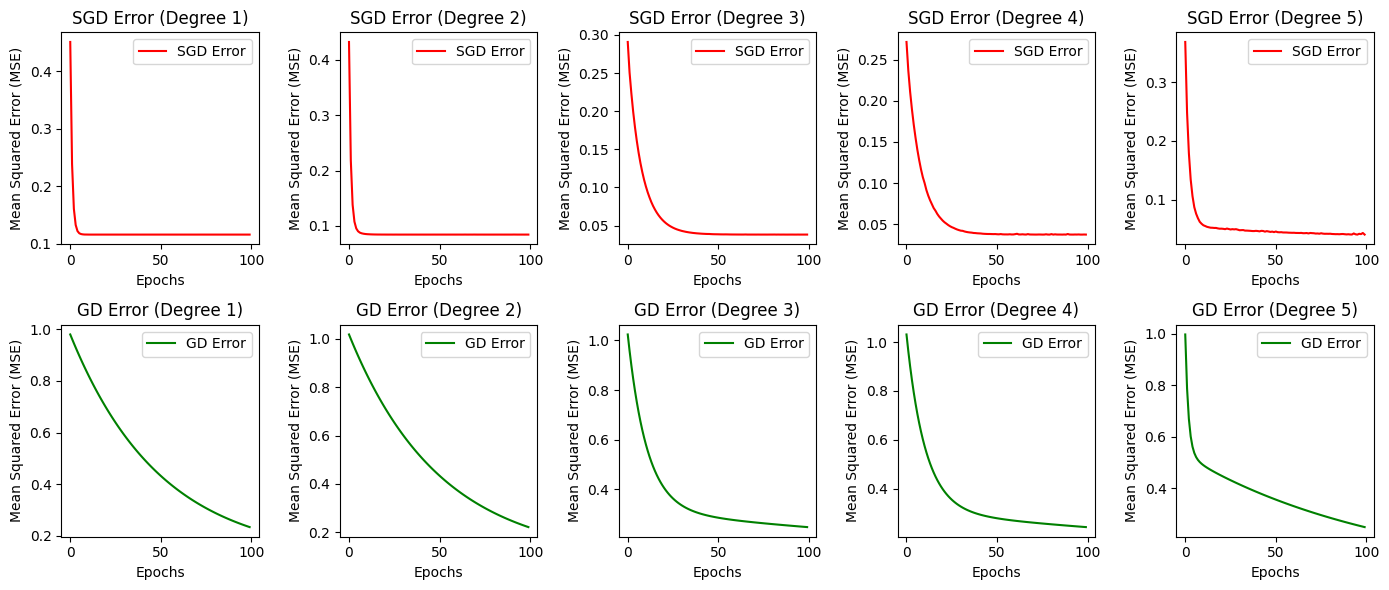

In [126]:
#with predifined function PolynomialFeatures
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
random.seed(42)
# Load the data
data = pd.read_csv('/Users/negin/Desktop/first year/New folder (2)/static/Homework Math/poly_regression_large.csv')
X = data['x'].values.reshape(-1, 1)
y = data['y'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Hyperparameters
learning_rate = 0.01
batch_size = 16
epochs = 100

# Stochastic Gradient Descent
def stochastic_gradient_descent(X, y, theta, learning_rate, batch_size, epochs):
    m = len(y)
    mse_list = []  # List to track MSE during training
    for epoch in range(epochs):
        # Shuffle the data
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]
        
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            
            predictions = X_batch @ theta
            errors = predictions - y_batch
            gradient = (1 / len(X_batch)) * (X_batch.T @ errors)
            theta -= learning_rate * gradient
        
        # Compute MSE at the end of each epoch
        predictions = X @ theta
        mse = mean_squared_error(y, predictions)
        mse_list.append(mse)
    return theta, mse_list

# Gradient Descent
def gradient_descent(X, y, theta, learning_rate, epochs):
    m = len(y)
    mse_list = []  # List to track MSE during training
    for epoch in range(epochs):
        predictions = X @ theta
        errors = predictions - y
        gradient = (1 / m) * (X.T @ errors)
        theta -= learning_rate * gradient
        
        # Compute MSE at the end of each epoch
        mse = mean_squared_error(y, predictions)
        mse_list.append(mse)
    return theta, mse_list

# Evaluate Models with varying degree k
def evaluate_models(X_train, y_train, X_test, y_test, degree, learning_rate, batch_size, epochs):
    # Initialize theta
    theta_sgd = np.random.randn(X_train.shape[1]) * 0.01
    theta_gd = np.random.randn(X_train.shape[1]) * 0.01

    # Train with SGD
    theta_sgd, mse_sgd = stochastic_gradient_descent(X_train, y_train, theta_sgd, learning_rate, batch_size, epochs)

    # Train with GD
    theta_gd, mse_gd = gradient_descent(X_train, y_train, theta_gd, learning_rate, epochs)

    # Predictions
    y_pred_sgd = X_test @ theta_sgd
    y_pred_gd = X_test @ theta_gd

    # Compute MSE for test set
    mse_sgd_test = mean_squared_error(y_test, y_pred_sgd)
    mse_gd_test = mean_squared_error(y_test, y_pred_gd)

    return theta_sgd, theta_gd, mse_sgd, mse_gd, mse_sgd_test, mse_gd_test, mse_sgd, mse_gd

# Vary the degree of the polynomial and observe the results
degrees = [1,2, 3, 4, 5]  # Test different polynomial degrees
results = {}

for degree in degrees:
    print(f"\nEvaluating with Polynomial Degree = {degree}")
    
    # Generate polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    # Run evaluation for this degree
    theta_sgd, theta_gd, mse_sgd, mse_gd, mse_sgd_test, mse_gd_test, mse_sgd_train, mse_gd_train = evaluate_models(
        X_train_poly, y_train_scaled, X_test_poly, y_test_scaled, degree, learning_rate, batch_size, epochs)

    # Store results
    results[degree] = {
        'theta_sgd': theta_sgd,
        'theta_gd': theta_gd,
        'mse_sgd_train': mse_sgd_train[-1],
        'mse_gd_train': mse_gd_train[-1],
        'mse_sgd_test': mse_sgd_test,
        'mse_gd_test': mse_gd_test,
        'mse_sgd': mse_sgd,
        'mse_gd': mse_gd
    }

    print(f"Parameters (SGD) for degree {degree}: {theta_sgd}")
    print(f"Parameters (GD) for degree {degree}: {theta_gd}")
    print(f"MSE (SGD - Train) for degree {degree}: {mse_sgd_train[-1]}")
    print(f"MSE (GD - Train) for degree {degree}: {mse_gd_train[-1]}")
    print(f"MSE (SGD - Test) for degree {degree}: {mse_sgd_test}")
    print(f"MSE (GD - Test) for degree {degree}: {mse_gd_test}")

# Visualize the training error change for different degrees
fig, axes = plt.subplots(2, len(degrees), figsize=(14, 6))

for i, degree in enumerate(degrees):
    axes[0, i].plot(range(epochs), results[degree]['mse_sgd'], color="red", label="SGD Error")
    axes[0, i].set_title(f"SGD Error (Degree {degree})")
    axes[0, i].set_xlabel("Epochs")
    axes[0, i].set_ylabel("Mean Squared Error (MSE)")
    axes[0, i].legend()

    axes[1, i].plot(range(epochs), results[degree]['mse_gd'], color="green", label="GD Error")
    axes[1, i].set_title(f"GD Error (Degree {degree})")
    axes[1, i].set_xlabel("Epochs")
    axes[1, i].set_ylabel("Mean Squared Error (MSE)")
    axes[1, i].legend()

plt.tight_layout()
plt.show()

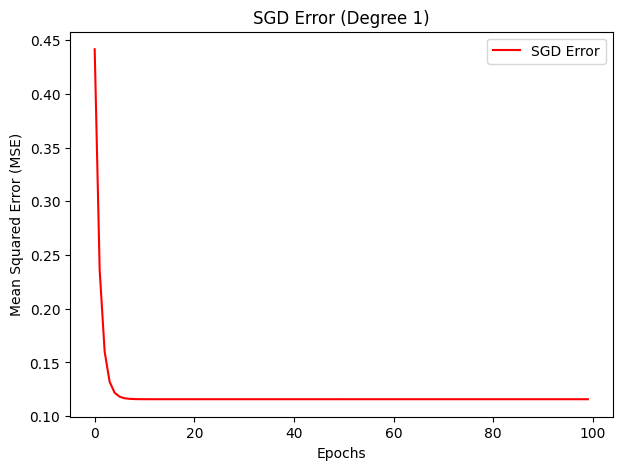

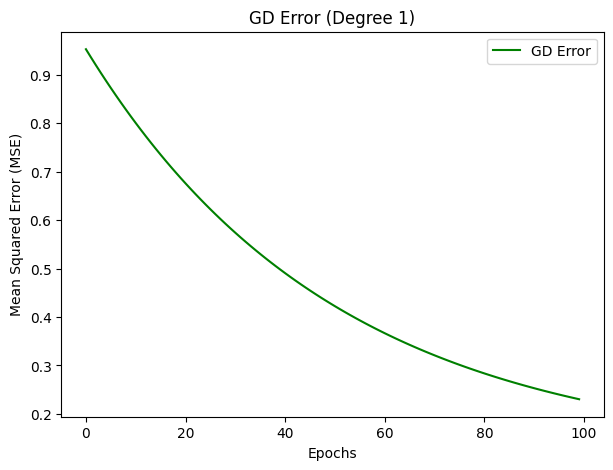

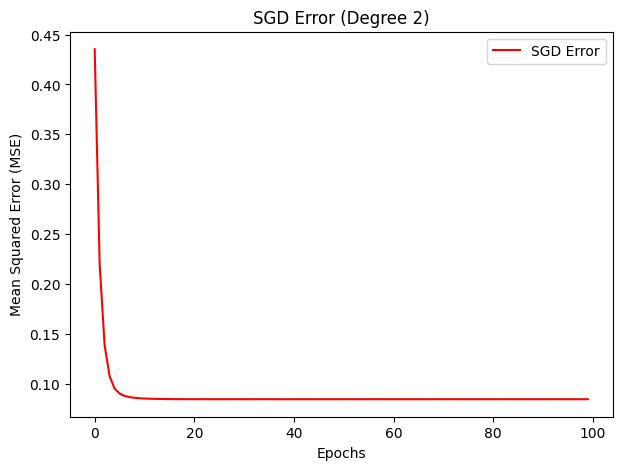

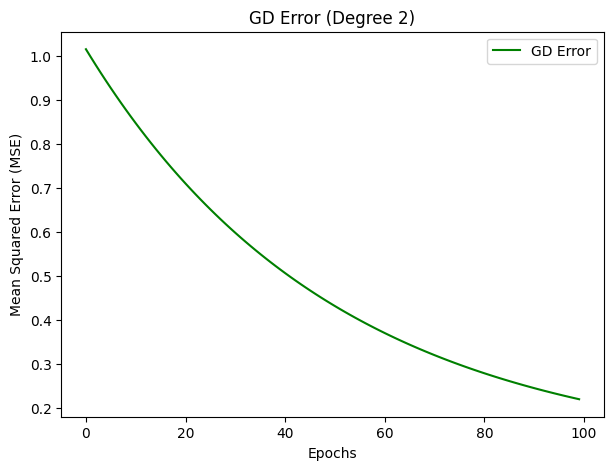

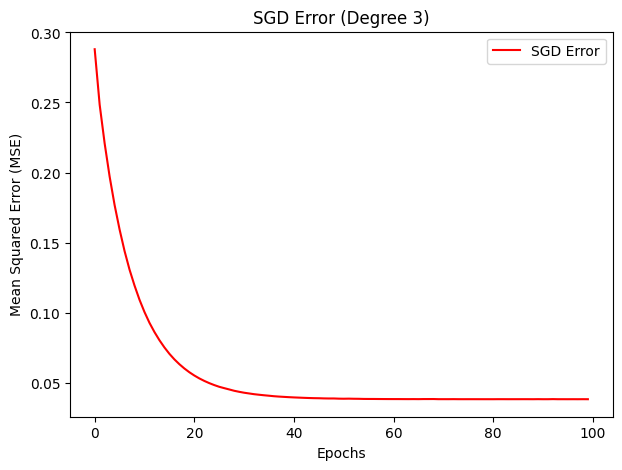

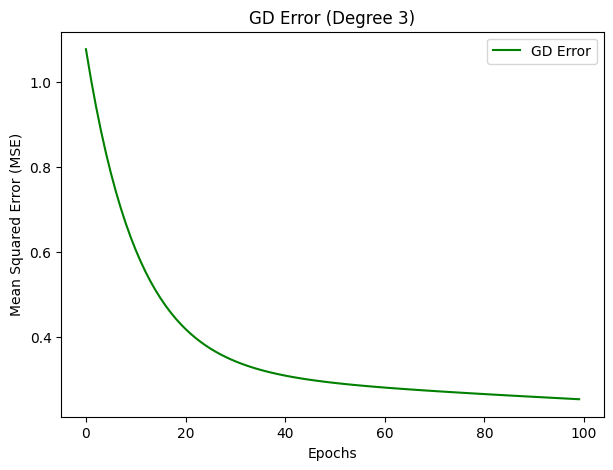

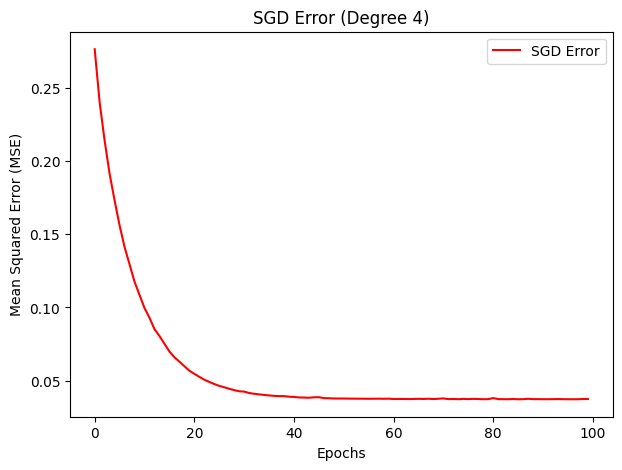

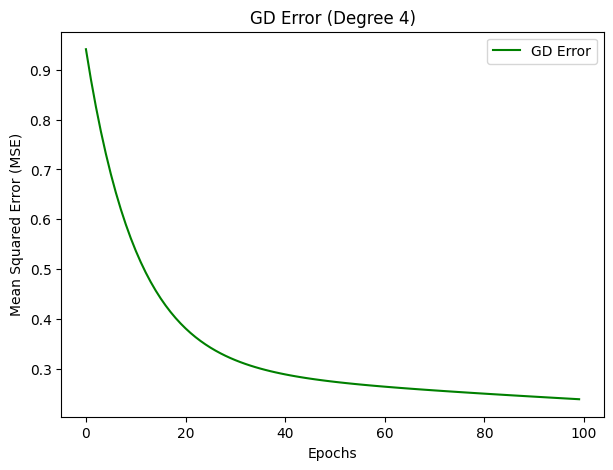

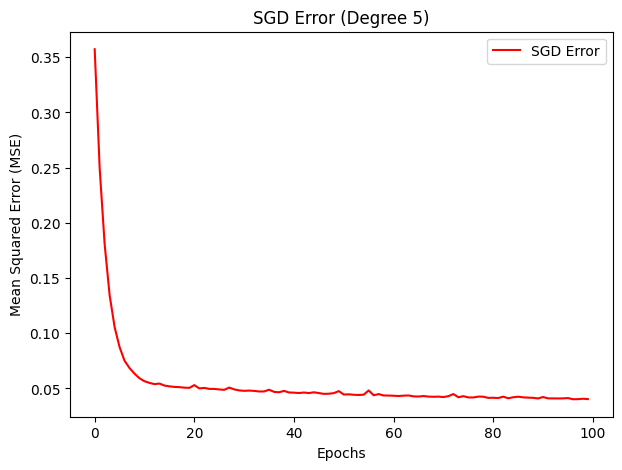

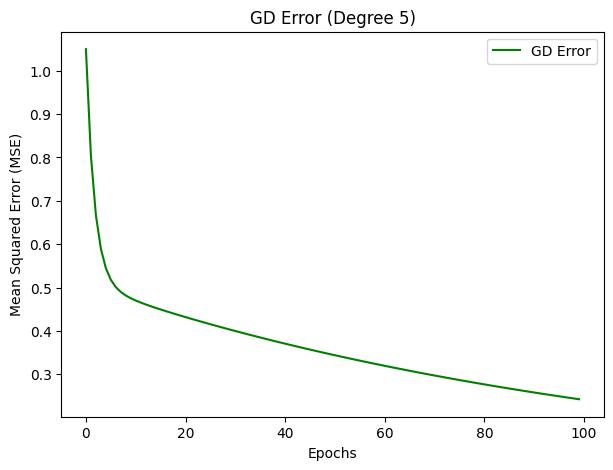

In [123]:
# Visualize the training error change for different degrees separately
for i, degree in enumerate(degrees):
    # Plot SGD error
    plt.figure(figsize=(7, 5))
    plt.plot(range(epochs), results[degree]['mse_sgd'], color="red", label="SGD Error")
    plt.title(f"SGD Error (Degree {degree})")
    plt.xlabel("Epochs")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.legend()
    plt.show()

    # Plot GD error
    plt.figure(figsize=(7, 5))
    plt.plot(range(epochs), results[degree]['mse_gd'], color="green", label="GD Error")
    plt.title(f"GD Error (Degree {degree})")
    plt.xlabel("Epochs")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.legend()
    plt.show()


Evaluating with Polynomial Degree = 1
Parameters (SGD) for degree 1: [4.18974488e-04 9.39889043e-01]
Parameters (GD) for degree 1: [-0.00163912  0.6054074 ]
MSE (SGD - Train) for degree 1: 0.11575832060521986
MSE (GD - Train) for degree 1: 0.2302192333758604
MSE (SGD - Test) for degree 1: 0.13146299547118792
MSE (GD - Test) for degree 1: 0.22474295224733487

Evaluating with Polynomial Degree = 2
Parameters (SGD) for degree 2: [ 0.19910355  0.93925454 -0.19692343]
Parameters (GD) for degree 2: [ 0.04251085  0.59280076 -0.08797349]
MSE (SGD - Train) for degree 2: 0.08442703419430955
MSE (GD - Train) for degree 2: 0.2193897317112452
MSE (SGD - Test) for degree 2: 0.09126926719763695
MSE (GD - Test) for degree 2: 0.21405374528458743

Evaluating with Polynomial Degree = 3
Parameters (SGD) for degree 3: [ 0.19714812  1.43410843 -0.19927228 -0.27559439]
Parameters (GD) for degree 3: [ 0.04279649  0.3079469  -0.08723757  0.26752433]
MSE (SGD - Train) for degree 3: 0.0381607188033305
MSE (GD -

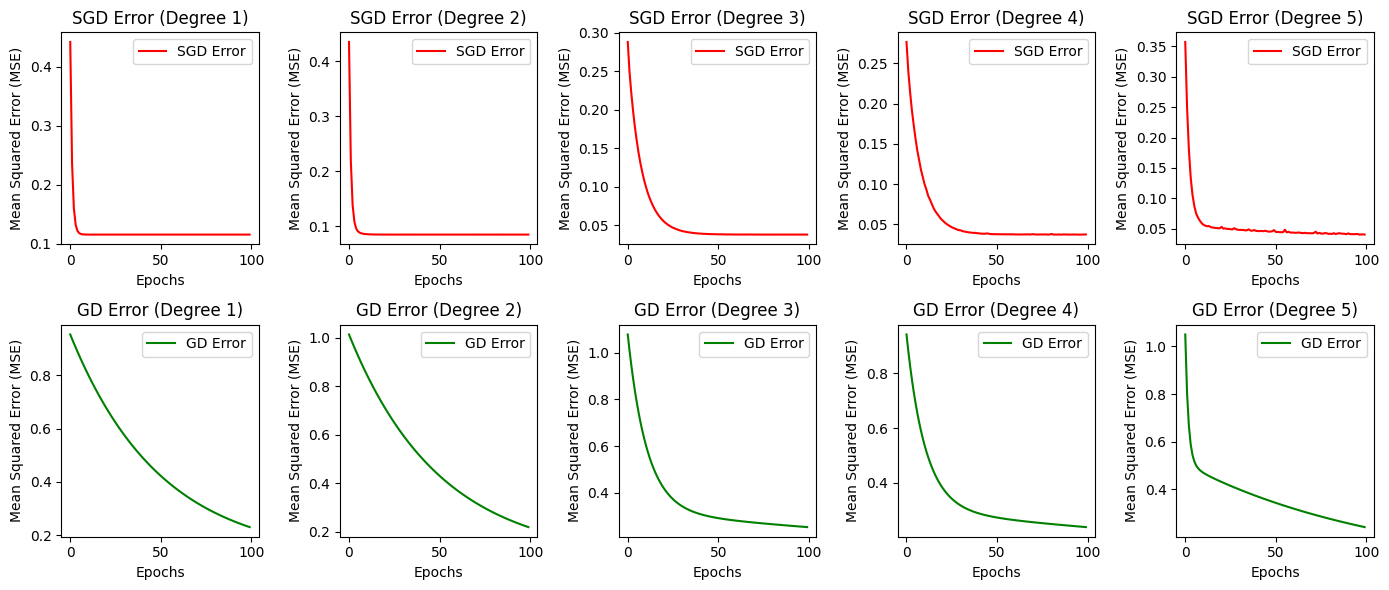

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import itertools

# Load the data
data = pd.read_csv('/Users/negin/Desktop/first year/New folder (2)/static/Homework Math/poly_regression_large.csv')
X = data['x'].values.reshape(-1, 1)
y = data['y'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Hyperparameters
learning_rate = 0.01
batch_size = 16
epochs = 100

# Stochastic Gradient Descent
def stochastic_gradient_descent(X, y, theta, learning_rate, batch_size, epochs):
    m = len(y)
    mse_list = []  # List to track MSE during training
    for epoch in range(epochs):
        # Shuffle the data
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]
        
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            
            predictions = X_batch @ theta
            errors = predictions - y_batch
            gradient = (1 / len(X_batch)) * (X_batch.T @ errors)
            theta -= learning_rate * gradient
        
        # Compute MSE at the end of each epoch
        predictions = X @ theta
        mse = mean_squared_error(y, predictions)
        mse_list.append(mse)
    return theta, mse_list

# Gradient Descent
def gradient_descent(X, y, theta, learning_rate, epochs):
    m = len(y)
    mse_list = []  # List to track MSE during training
    for epoch in range(epochs):
        predictions = X @ theta
        errors = predictions - y
        gradient = (1 / m) * (X.T @ errors)
        theta -= learning_rate * gradient
        
        # Compute MSE at the end of each epoch
        mse = mean_squared_error(y, predictions)
        mse_list.append(mse)
    return theta, mse_list

# Evaluate Models with varying degree k
def evaluate_models(X_train, y_train, X_test, y_test, degree, learning_rate, batch_size, epochs):
    # Initialize theta
    theta_sgd = np.random.randn(X_train.shape[1]) * 0.01
    theta_gd = np.random.randn(X_train.shape[1]) * 0.01

    # Train with SGD
    theta_sgd, mse_sgd = stochastic_gradient_descent(X_train, y_train, theta_sgd, learning_rate, batch_size, epochs)

    # Train with GD
    theta_gd, mse_gd = gradient_descent(X_train, y_train, theta_gd, learning_rate, epochs)

    # Predictions
    y_pred_sgd = X_test @ theta_sgd
    y_pred_gd = X_test @ theta_gd

    # Compute MSE for test set
    mse_sgd_test = mean_squared_error(y_test, y_pred_sgd)
    mse_gd_test = mean_squared_error(y_test, y_pred_gd)

    return theta_sgd, theta_gd, mse_sgd, mse_gd, mse_sgd_test, mse_gd_test, mse_sgd, mse_gd

# Vary the degree of the polynomial and observe the results
degrees = [1, 2, 3, 4, 5]  # Test different polynomial degrees
results = {}
def create_polynomial_features(X, k):
    """
    Create polynomial features manually (including interaction terms).
    """
    n_samples, n_features = X.shape
    features = [np.ones(n_samples)]  # Include a column of ones for the bias term (degree 0)

    # Iterate over each degree from 1 to the specified degree
    for d in range(1, k + 1):
        for comb in itertools.combinations_with_replacement(range(n_features), d):
            term = np.prod([X[:, i] ** (comb.count(i)) for i in range(n_features)], axis=0)
            features.append(term)

    return np.column_stack(features)
for degree in degrees:
    print(f"\nEvaluating with Polynomial Degree = {degree}")
    
    # Generate polynomial features
    X_train_poly = create_polynomial_features(X_train_scaled,k=degree)
    X_test_poly = create_polynomial_features(X_test_scaled,k=degree)

    # X_train_poly = poly.fit_transform(X_train_scaled)
    # X_test_poly = poly.transform(X_test_scaled)

    # Run evaluation for this degree
    theta_sgd, theta_gd, mse_sgd, mse_gd, mse_sgd_test, mse_gd_test, mse_sgd_train, mse_gd_train = evaluate_models(
        X_train_poly, y_train_scaled, X_test_poly, y_test_scaled, degree, learning_rate, batch_size, epochs)

    # Store results
    results[degree] = {
        'theta_sgd': theta_sgd,
        'theta_gd': theta_gd,
        'mse_sgd_train': mse_sgd_train[-1],
        'mse_gd_train': mse_gd_train[-1],
        'mse_sgd_test': mse_sgd_test,
        'mse_gd_test': mse_gd_test,
        'mse_sgd': mse_sgd,
        'mse_gd': mse_gd
    }

    print(f"Parameters (SGD) for degree {degree}: {theta_sgd}")
    print(f"Parameters (GD) for degree {degree}: {theta_gd}")
    print(f"MSE (SGD - Train) for degree {degree}: {mse_sgd_train[-1]}")
    print(f"MSE (GD - Train) for degree {degree}: {mse_gd_train[-1]}")
    print(f"MSE (SGD - Test) for degree {degree}: {mse_sgd_test}")
    print(f"MSE (GD - Test) for degree {degree}: {mse_gd_test}")

# Visualize the training error change for different degrees
fig, axes = plt.subplots(2, len(degrees), figsize=(14, 6))

for i, degree in enumerate(degrees):
    axes[0, i].plot(range(epochs), results[degree]['mse_sgd'], color="red", label="SGD Error")
    axes[0, i].set_title(f"SGD Error (Degree {degree})")
    axes[0, i].set_xlabel("Epochs")
    axes[0, i].set_ylabel("Mean Squared Error (MSE)")
    axes[0, i].legend()

    axes[1, i].plot(range(epochs), results[degree]['mse_gd'], color="green", label="GD Error")
    axes[1, i].set_title(f"GD Error (Degree {degree})")
    axes[1, i].set_xlabel("Epochs")
    axes[1, i].set_ylabel("Mean Squared Error (MSE)")
    axes[1, i].legend()

plt.tight_layout()
plt.show()

### Parameters:
- **SGD Parameters**: 
   - \( \theta_{\text{SGD}} = [ 0.16099206,  1.43450444, -0.07499406, -0.27289835, -0.04636222] \)
   - These values are fairly close to the true parameters \( \theta^* = [0, 0, 4, 0, -3] \) in terms of magnitude, but not exact. This suggests that the Stochastic Gradient Descent (SGD) approach has learned a decent approximation of the true parameters, although there is some deviation.
  
- **GD Parameters**:
   - \( \theta_{\text{GD}} = [ 0.06687605,  0.30810065, 0.00749848, 0.2675689, -0.0635346 ] \)
   - These parameters are quite different from the true parameters as well. The \( \theta_2 \) (which should be 4) is 0.308, and \( \theta_4 \) (which should be -3) is 0.267, indicating that the Gradient Descent (GD) model might not have converged as well as the SGD model.

# for small dataset


Evaluating with Polynomial Degree = 2
Parameters (SGD) for degree 2: [ 0.13542204  0.90962992 -0.17023411]
Parameters (GD) for degree 2: [ 0.03811733  0.58691413 -0.08779205]
MSE (SGD - Full) for degree 2: 0.12241621140317469
MSE (GD - Full) for degree 2: 0.24459944704076492

Evaluating with Polynomial Degree = 3
Parameters (SGD) for degree 3: [ 0.15106397  0.74437241 -0.19049079  0.01822407]
Parameters (GD) for degree 3: [ 0.03984525  0.33376198 -0.08858121  0.2326784 ]
MSE (SGD - Full) for degree 3: 0.150357292119849
MSE (GD - Full) for degree 3: 0.29902834973065984

Evaluating with Polynomial Degree = 4
Parameters (SGD) for degree 4: [ 0.13280638  0.72180091  0.02914869  0.03915877 -0.08279973]
Parameters (GD) for degree 4: [ 0.05897055  0.32816523 -0.00305206  0.23536366 -0.0593305 ]
MSE (SGD - Full) for degree 4: 0.1542061359252437
MSE (GD - Full) for degree 4: 0.290853588532657

Evaluating with Polynomial Degree = 5
Parameters (SGD) for degree 5: [ 0.12175596  0.76840046 -0.0053

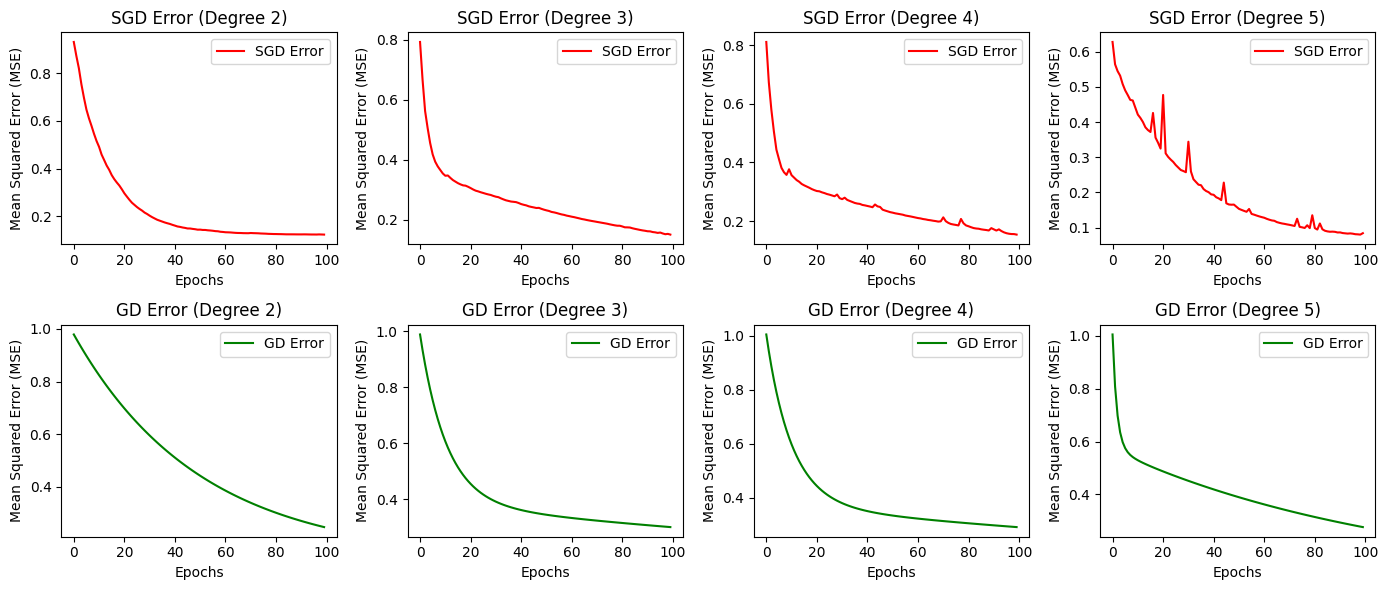

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

# Load the data
data = pd.read_csv('/Users/negin/Desktop/first year/New folder (2)/static/Homework Math/poly_regression_small.csv')
X = data['x'].values.reshape(-1, 1)
y = data['y'].values

# Normalize the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# Hyperparameters
learning_rate = 0.01
batch_size = 16
epochs = 100

# Stochastic Gradient Descent
def stochastic_gradient_descent(X, y, theta, learning_rate, batch_size, epochs):
    m = len(y)
    mse_list = []  # List to track MSE during training
    for epoch in range(epochs):
        # Shuffle the data
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]
        
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            
            predictions = X_batch @ theta
            errors = predictions - y_batch
            gradient = (1 / len(X_batch)) * (X_batch.T @ errors)
            theta -= learning_rate * gradient
        
        # Compute MSE at the end of each epoch
        predictions = X @ theta
        mse = mean_squared_error(y, predictions)
        mse_list.append(mse)
    return theta, mse_list

# Gradient Descent
def gradient_descent(X, y, theta, learning_rate, epochs):
    m = len(y)
    mse_list = []  # List to track MSE during training
    for epoch in range(epochs):
        predictions = X @ theta
        errors = predictions - y
        gradient = (1 / m) * (X.T @ errors)
        theta -= learning_rate * gradient
        
        # Compute MSE at the end of each epoch
        mse = mean_squared_error(y, predictions)
        mse_list.append(mse)
    return theta, mse_list

# Evaluate Model with varying degree k
def evaluate_model(X, y, degree, learning_rate, batch_size, epochs):
    # Generate polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    # Initialize theta
    theta_sgd = np.random.randn(X_poly.shape[1]) * 0.01
    theta_gd = np.random.randn(X_poly.shape[1]) * 0.01

    # Train with SGD
    theta_sgd, mse_sgd = stochastic_gradient_descent(X_poly, y, theta_sgd, learning_rate, batch_size, epochs)

    # Train with GD
    theta_gd, mse_gd = gradient_descent(X_poly, y, theta_gd, learning_rate, epochs)

    # Predictions
    y_pred_sgd = X_poly @ theta_sgd
    y_pred_gd = X_poly @ theta_gd

    # Compute MSE for the full dataset
    mse_sgd_full = mean_squared_error(y, y_pred_sgd)
    mse_gd_full = mean_squared_error(y, y_pred_gd)

    return theta_sgd, theta_gd, mse_sgd, mse_gd, mse_sgd_full, mse_gd_full

# Vary the degree of the polynomial and observe the results
degrees = [2, 3, 4, 5]  # Test different polynomial degrees
results = {}

for degree in degrees:
    print(f"\nEvaluating with Polynomial Degree = {degree}")
    
    # Run evaluation for this degree
    theta_sgd, theta_gd, mse_sgd, mse_gd, mse_sgd_full, mse_gd_full = evaluate_model(
        X_scaled, y_scaled, degree, learning_rate, batch_size, epochs)

    # Store results
    results[degree] = {
        'theta_sgd': theta_sgd,
        'theta_gd': theta_gd,
        'mse_sgd_full': mse_sgd_full,
        'mse_gd_full': mse_gd_full,
        'mse_sgd': mse_sgd,
        'mse_gd': mse_gd
    }

    print(f"Parameters (SGD) for degree {degree}: {theta_sgd}")
    print(f"Parameters (GD) for degree {degree}: {theta_gd}")
    print(f"MSE (SGD - Full) for degree {degree}: {mse_sgd_full}")
    print(f"MSE (GD - Full) for degree {degree}: {mse_gd_full}")

# Visualize the training error change for different degrees
fig, axes = plt.subplots(2, len(degrees), figsize=(14, 6))

for i, degree in enumerate(degrees):
    axes[0, i].plot(range(epochs), results[degree]['mse_sgd'], color="red", label="SGD Error")
    axes[0, i].set_title(f"SGD Error (Degree {degree})")
    axes[0, i].set_xlabel("Epochs")
    axes[0, i].set_ylabel("Mean Squared Error (MSE)")
    axes[0, i].legend()

    axes[1, i].plot(range(epochs), results[degree]['mse_gd'], color="green", label="GD Error")
    axes[1, i].set_title(f"GD Error (Degree {degree})")
    axes[1, i].set_xlabel("Epochs")
    axes[1, i].set_ylabel("Mean Squared Error (MSE)")
    axes[1, i].legend()

plt.tight_layout()
plt.show()

### Interpretation of Results

1. **Polynomial Degree = 2**
   - SGD performs better than GD with a lower MSE. The parameters from SGD suggest a better fit for the data.
   - GD's MSE is higher, indicating it struggles to find an optimal set of parameters.

2. **Polynomial Degree = 3**
   - SGD continues to outperform GD in terms of MSE, showing better convergence with more complex data.
   - The parameters for SGD are more refined, whereas GD shows a less optimal fit.

3. **Polynomial Degree = 4**
   - SGD still yields a lower MSE compared to GD, suggesting better optimization in higher polynomial degrees.
   - The difference in parameters grows, reflecting the increased complexity of the model.

4. **Polynomial Degree = 5**
   - SGD shows the lowest MSE again, reinforcing its superior performance for higher-degree polynomials.
   - GD’s parameters continue to be less optimal, and its MSE is higher, confirming its limitations with more complex models.

### Key Observations:
- **SGD outperforms GD** consistently across all polynomial degrees, achieving **lower MSE** values.
- As the degree increases, **SGD’s parameters become more complex**, but still yield better results.
- Higher-degree polynomials improve performance but may risk overfitting the data.